![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 3. Interferometers I - MZI


Today we will work on the design and modeling of an **Mach-Zenhder Interferometer (MZI)** used in integrated photonic circuits. We will perform simulations that will allow us to understand how it operates.


## 0.1 General libraries

In [2]:
import gdsfactory as gf
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

import numpy as np
import sax
from gdsfactory.generic_tech import get_generic_pdk
from scipy import constants
from scipy.constants import c
from scipy.interpolate import interp1d

import gplugins.sax as gs
from gplugins.common.config import PATH

C:\Users\cfp\AppData\Local\Temp\ipykernel_13724\3896563056.py:10: DeprecationWarning: The 'gdsfactory.generic_tech' module is deprecated and will be removed in a future version. Please update your imports to use 'gdsfactory.gpdk' instead:
  from gdsfactory.gpdk import LAYER, LAYER_STACK, get_generic_pdk
Or for submodules:
  from gdsfactory.gpdk.layer_map import LAYER
  from gdsfactory.gpdk.layer_stack import LAYER_STACK
  from gdsfactory.generic_tech import get_generic_pdk


## 1. MZI modeling
Let's compute the transfer function of a MZI

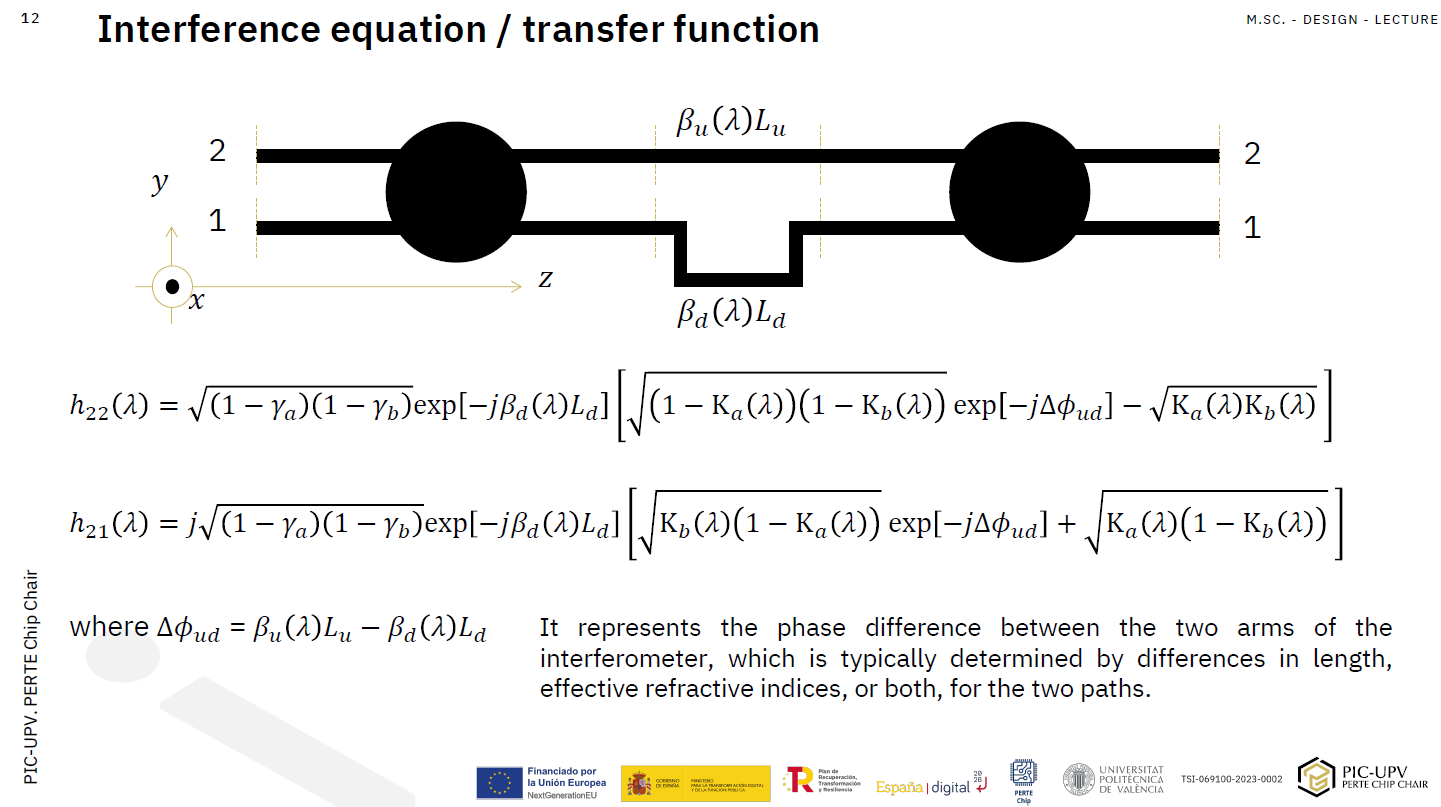

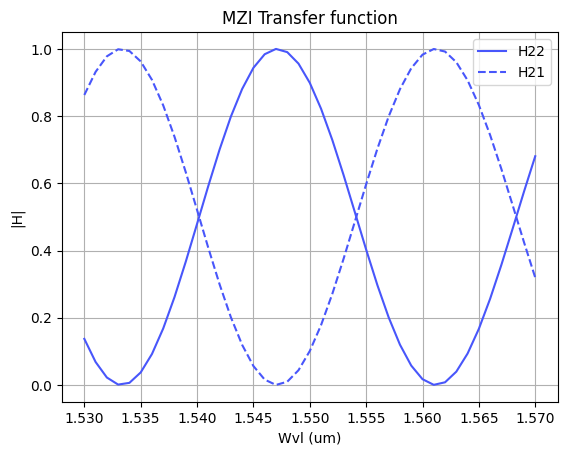

In [3]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 5; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5) # Hace un arrary con el mismo valor de acoplamiento (0.5) para todas las longitudes de onda
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.legend()
plt.grid(True)

plt.show()

**Assesment 1.** Please, provide one example of each one of the configurations studied during MZI lecture:
1. Balenced configuration
2. Unbalanced configuration
    1.   Phase difference
    2.   Delay imbalance

#### 1. Balenced configuration

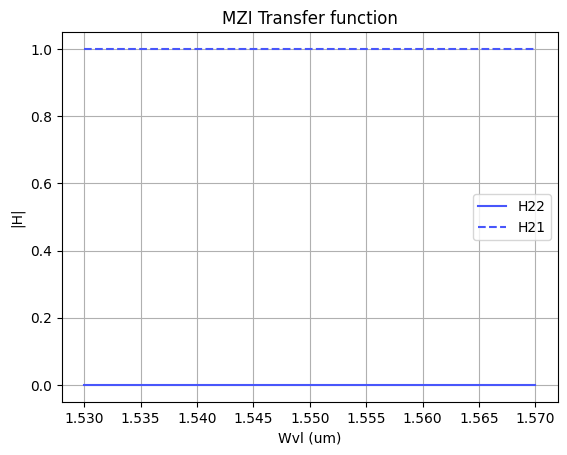

In [4]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 25; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.legend()
plt.grid(True)

plt.show()

#### 2. Unbalanced configuration
1.   Phase difference

Diferente fase (diferente índice de propagación) en cada brazo pero misma longitud. Esto se consigue cambiando el índice efectivo, que se hace cambiando el material de uno de los brazos

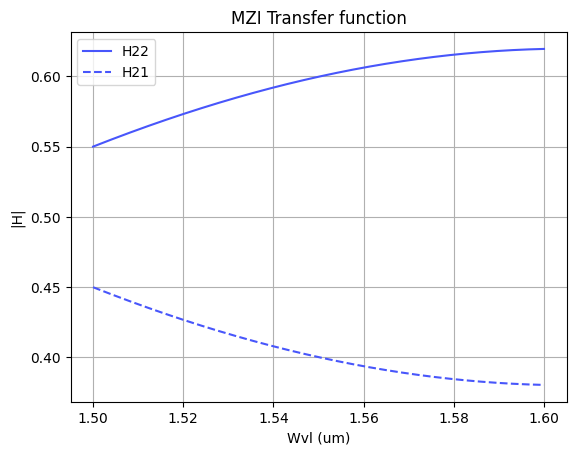

In [5]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
#SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

#wvl = SOI[:, 0]
#neffu = SOI[:, 3] #balanced configuration // (neff TE mode)   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
#neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_air = np.loadtxt('SiN-h300nm-w1000nm-air.txt', skiprows=1, delimiter='\t')

wvl0 = SiN_clad[:, 0]
neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
neffd0 = SiN_air[:, 3] #balanced configuration // (neff TE mode)

interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 25; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.legend()
plt.grid(True)

plt.show()

2.   Delay imbalance

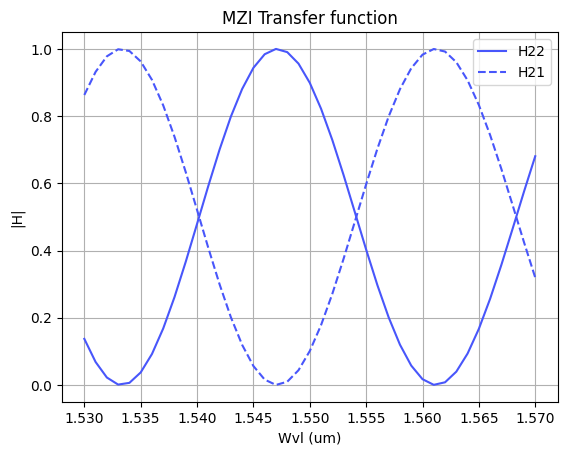

In [6]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 5; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.legend()
plt.grid(True)

plt.show()

Compute also some examples with α≠0 and γ≠0

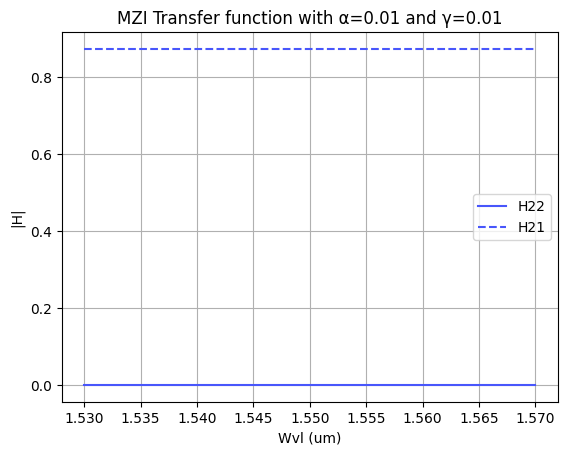

In [7]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0.01 #loss case [dB/um]
alphad = 0.01; #loss case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 25; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0.01; # excess loss
gamma_b = 0.01; # excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function with α=0.01 and γ=0.01')
plt.legend()
plt.grid(True)

plt.show()

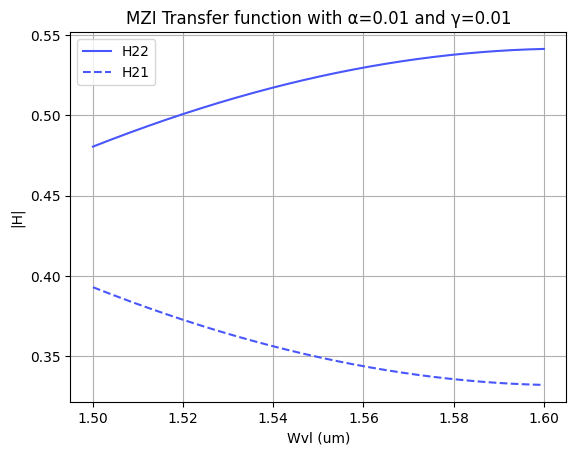

In [9]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
#SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

#wvl = SOI[:, 0]
#neffu = SOI[:, 3] #balanced configuration // (neff TE mode)   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
#neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_air = np.loadtxt('SiN-h300nm-w1000nm-air.txt', skiprows=1, delimiter='\t')

wvl0 = SiN_clad[:, 0]
neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
neffd0 = SiN_air[:, 3] #balanced configuration // (neff TE mode)

interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0.01 #loss case [dB/um]
alphad = 0.01; #loss case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 25; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0.01; #excess loss
gamma_b = 0.01; #excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function with α=0.01 and γ=0.01')
plt.legend()
plt.grid(True)

plt.show()

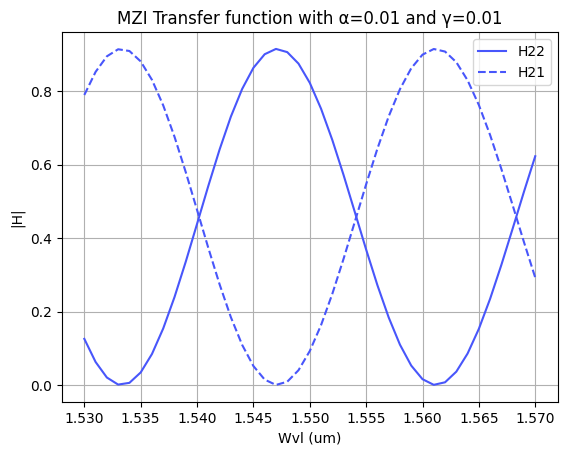

In [11]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0.01 #loss case [dB/um]
alphad = 0.01; #loss case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 5; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0.01; #excess loss
gamma_b = 0.01; #excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function with α=0.01 and γ=0.01')
plt.legend()
plt.grid(True)

plt.show()

**Assesment 2.** Taking into account the n_{eff} values for the SOI cross-section, what would be the path difference ($\Delta L$ = $L_u$ - $L_d$) needed to obtain a Free Spectral Range of 40 nm? Introduce the obtained value in the model to check the MZI response. Hint: We assume 1550 nm as the central design wavelength ($\lambda _0$=1550 nm).

In [ ]:
FSR = 0.04
diff_L = (1.55)**2 / (FSR * neffu)
print(f"FSR: {FSR} um, Diff_L: {diff_L} um")

FSR: 0.04 um, Diff_L: [25.22850038 25.2416474  25.25491433 25.2681952  25.28149006 25.29479891
 25.30801514 25.32135193 25.3347028  25.34806774 25.3614468  25.37483999
 25.38824733 25.40166884 25.41499702 25.42844684 25.4419109  25.45538923
 25.46888185 25.48238878 25.49591004 25.50944566 25.52299566 25.53656006
 25.55013889 25.56373217 25.57733991 25.59096216 25.60459892 25.61825022
 25.63191608 25.64559654 25.6592916  25.67311104 25.68683551 25.70057467
 25.71432853 25.72809712 25.74188046 25.75567858 25.7694915 ] um


In [ ]:
FSR = 0.04
diff_L = (1.55)**2 / (FSR * neffu[20])  #[20] se usa el índice efectivo correspondiente a 1550 nm, que es el centro del rango espectral de interés
print(f"FSR: {FSR} um, Diff_L: {diff_L} um")

FSR: 0.04 um, Diff_L: 25.50944566196083 um


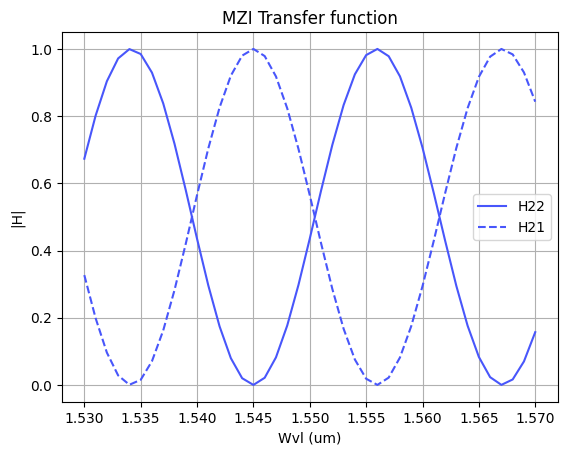

In [ ]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

FSR = 0.04
diff_L = (1.55)**2 / (FSR * neffu[20])  #[20] se usa el índice efectivo correspondiente a 1550 nm, que es el centro del rango espectral de interés


## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = Lu - diff_L; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.legend()
plt.grid(True)

plt.show()

## 2. MZI simulation implemented with SAX
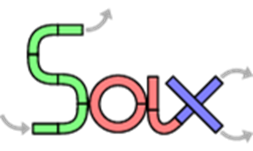

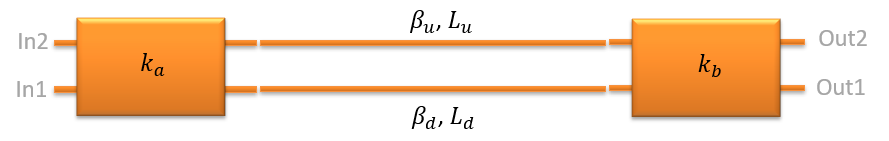


### 2.1 Components S matrix


In [14]:
# Waveguide Model

def waveguide(wl=1.55, neff=1.6072, length=10.0, loss=0.0) -> sax.SDict:
    phase = 2 * jnp.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase) # loss(dB/um)
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict


# Coupler Model

def coupler(coupling=0.5) -> sax.SDict:
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

El coeficiente de acoplamiento (kappa) nos va a dar la relación de potencia: in0-out1 o in1-out0.

### 2.2 MZI SAX Circuit Model

In [15]:
# MZI

mzi, info = sax.circuit(
    netlist={
        "instances": {
            "coup_a": "coupler",  # Definimos el acoplador de entrada coup_a
            "wvg_u": "waveguide",  # Definimos la guía superior wvg_u
            "wvg_d": "waveguide",  # Definimos la guía inferior wvg_d
            "coup_b": "coupler",  # Definimos el acoplador de salida coup_b
        },
        "connections": {
            "coup_a,out0": "wvg_d,in0",  # El out0 de coup_a se conecta al in0 de wvg_d
            "wvg_d,out0": "coup_b,in0",  # El out0 de wvg_d se conecta al in0 de coup_b
            "coup_a,out1": "wvg_u,in0",  # El out1 de coup_a se conecta al in0 de wvg_u
            "wvg_u,out0": "coup_b,in1",  # El out0 de wvg_u se conecta al in1 de coup_b
        },
        "ports": {
            "in0": "coup_a,in0",  # El puerto de entrada del circuito se conecta al in0 de coup_a
            "in1": "coup_a,in1",  # El puerto de entrada del circuito se conecta al in1 de coup_a
            "out0": "coup_b,out0",  # El puerto de salida del circuito se conecta al out0 de coup_b
            "out1": "coup_b,out1",  # El puerto de salida del circuito se conecta al out1 de coup_b
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)


### 2.3. MZI Modeling
**Assesment 3**: Now, we are going to implement the design parameters in the MZI model developed in SAX and compare the response obtained with that simulated by mathematical formulation.

This will help us to identify any error in the definition of the SAX model single components.

In order to implement the SAX model, take as example the following lines:

    mzi_test = mzi(wl=wl,
                coup_a = ...
                wvg_d={"length": l_d, "neff": ...},
                wvg_u={"length": l_u, "neff": ...},
                coup_b = ... )

    H00 = mzi_test["in0", "out0"]

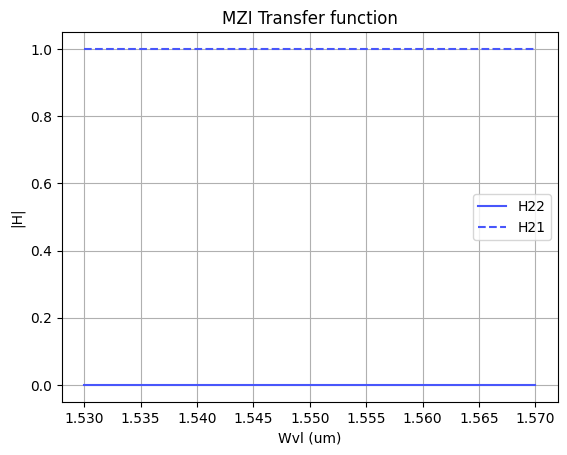

In [31]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 25; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Path length
Lu = 25; # um
Ld = 25; # um

# Coupling constant
K_a = np.full(wvl.shape, 0.5) # Hace un arrary con el mismo valor de acoplamiento (0.5) para todas las longitudes de onda
K_b = np.full(wvl.shape, 0.5)

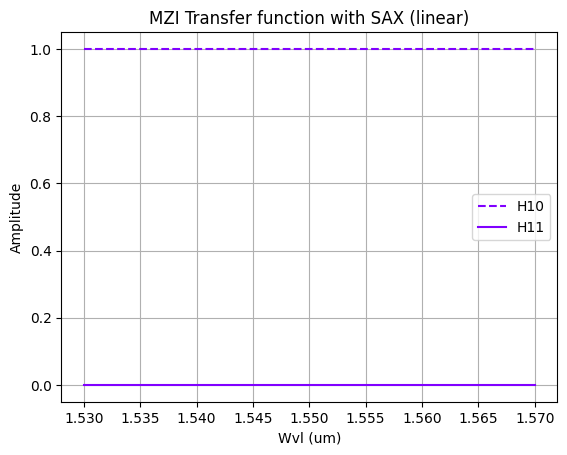

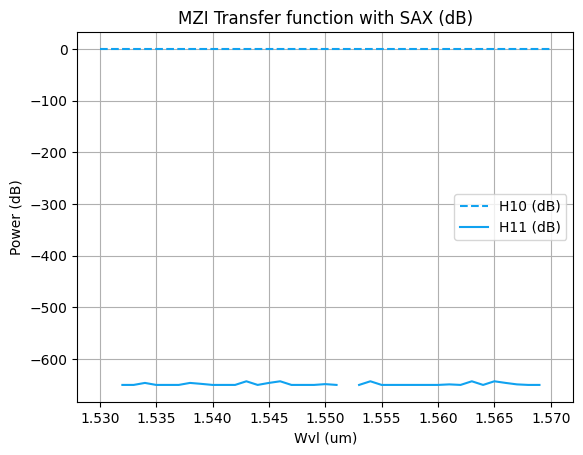

In [32]:
mzi_test = mzi(wl=wvl,
    coup_a = {"coupling": K_a},
    wvg_d={"length": Ld, "neff": neffd, "loss": alphad},
    wvg_u={"length": Lu, "neff": neffu, "loss": alphau},
    coup_b = {"coupling": K_b} )

H00 = mzi_test["in0", "out0"]
H10 = mzi_test["in0", "out1"]
H01 = mzi_test["in1", "out0"]
H11 = mzi_test["in1", "out1"]

H00_dB = 20 * jnp.log10(jnp.abs(H00)**2)  # Multiplicamos por 2 para normalizar la potencia de entrada
H10_dB = 20 * jnp.log10(jnp.abs(H10)**2)
H01_dB = 20 * jnp.log10(jnp.abs(H01)**2)
H11_dB = 20 * jnp.log10(jnp.abs(H11)**2)

# Plot
plt.figure()
#plt.plot(wvl, np.abs(H00)**2, linestyle='-', color=color[1], label='H00')
plt.plot(wvl, np.abs(H10)**2, linestyle='--', color=color[0], label='H10')
#plt.plot(wvl, np.abs(H01)**2, linestyle='--', color=color[2], label='H01')
plt.plot(wvl, np.abs(H11)**2, linestyle='-', color=color[0], label='H11')
plt.xlabel('Wvl (um)')
plt.ylabel('Amplitude')
plt.title('MZI Transfer function with SAX (linear)')
plt.legend()
plt.grid(True)

plt.figure()
#plt.plot(wvl, H00_dB, linestyle='-', color=color[1], label='H00 (dB)')
plt.plot(wvl, H10_dB, linestyle='--', color=color[2], label='H10 (dB)')
#plt.plot(wvl, H01_dB, linestyle='--', color=color[2], label='H01 (dB)')
plt.plot(wvl, H11_dB, linestyle='-', color=color[2], label='H11 (dB)')
plt.xlabel('Wvl (um)')
plt.ylabel('Power (dB)')
plt.title('MZI Transfer function with SAX (dB)')
plt.legend()
plt.grid(True)
plt.show()


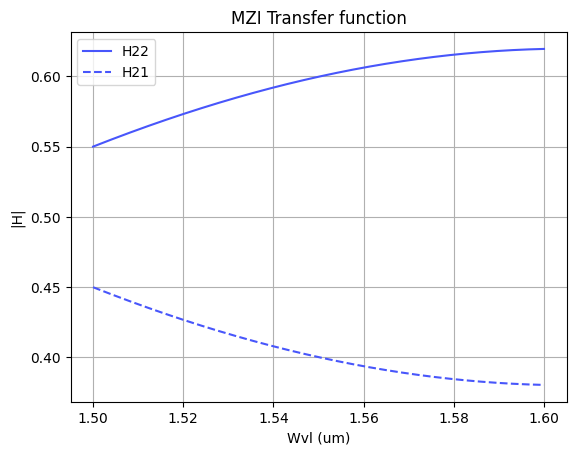

In [38]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
#SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

#wvl = SOI[:, 0]
#neffu = SOI[:, 3] #balanced configuration // (neff TE mode)   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
#neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_air = np.loadtxt('SiN-h300nm-w1000nm-air.txt', skiprows=1, delimiter='\t')

wvl0 = SiN_clad[:, 0]
neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
neffd0 = SiN_air[:, 3] #balanced configuration // (neff TE mode)

interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 25; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.legend()
plt.grid(True)

plt.show()

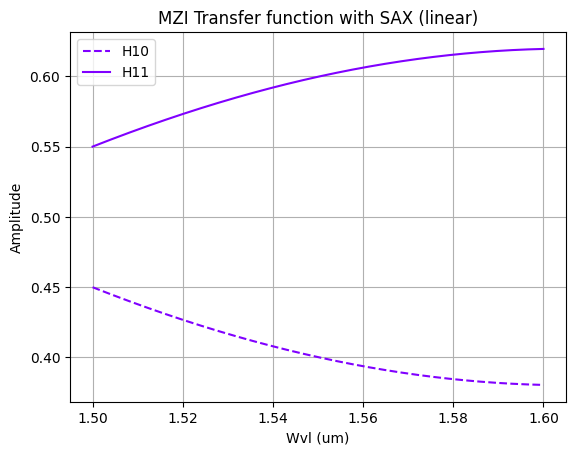

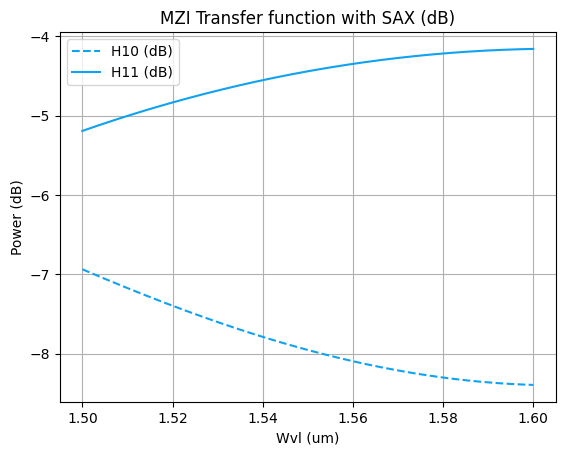

In [39]:
mzi_test = mzi(wl=wvl,
    coup_a = {"coupling": K_a},
    wvg_d={"length": Ld, "neff": neffd, "loss": alphad},
    wvg_u={"length": Lu, "neff": neffu, "loss": alphau},
    coup_b = {"coupling": K_b} )

H00 = mzi_test["in0", "out0"]
H10 = mzi_test["in0", "out1"]
H01 = mzi_test["in1", "out0"]
H11 = mzi_test["in1", "out1"]

H00_dB = 20 * jnp.log10(jnp.abs(H00)**2)  # Multiplicamos por 2 para normalizar la potencia de entrada
H10_dB = 20 * jnp.log10(jnp.abs(H10)**2)
H01_dB = 20 * jnp.log10(jnp.abs(H01)**2)
H11_dB = 20 * jnp.log10(jnp.abs(H11)**2)

# Plot
plt.figure()
#plt.plot(wvl, np.abs(H00)**2, linestyle='-', color=color[1], label='H00')
plt.plot(wvl, np.abs(H10)**2, linestyle='--', color=color[0], label='H10')
#plt.plot(wvl, np.abs(H01)**2, linestyle='--', color=color[2], label='H01')
plt.plot(wvl, np.abs(H11)**2, linestyle='-', color=color[0], label='H11')
plt.xlabel('Wvl (um)')
plt.ylabel('Amplitude')
plt.title('MZI Transfer function with SAX (linear)')
plt.legend()
plt.grid(True)

plt.figure()
#plt.plot(wvl, H00_dB, linestyle='-', color=color[1], label='H00 (dB)')
plt.plot(wvl, H10_dB, linestyle='--', color=color[2], label='H10 (dB)')
#plt.plot(wvl, H01_dB, linestyle='--', color=color[2], label='H01 (dB)')
plt.plot(wvl, H11_dB, linestyle='-', color=color[2], label='H11 (dB)')
plt.xlabel('Wvl (um)')
plt.ylabel('Power (dB)')
plt.title('MZI Transfer function with SAX (dB)')
plt.legend()
plt.grid(True)
plt.show()


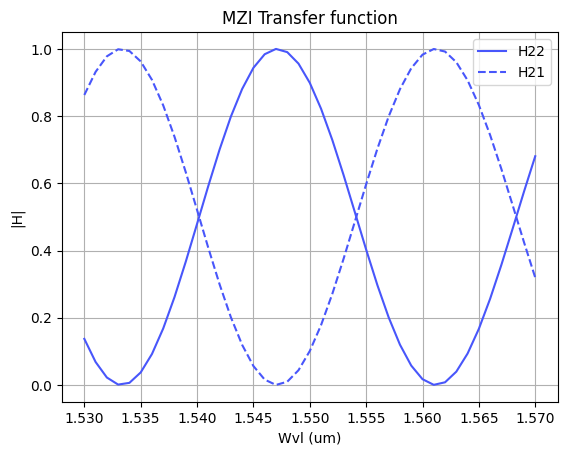

In [44]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 5; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.legend()
plt.grid(True)

plt.show()

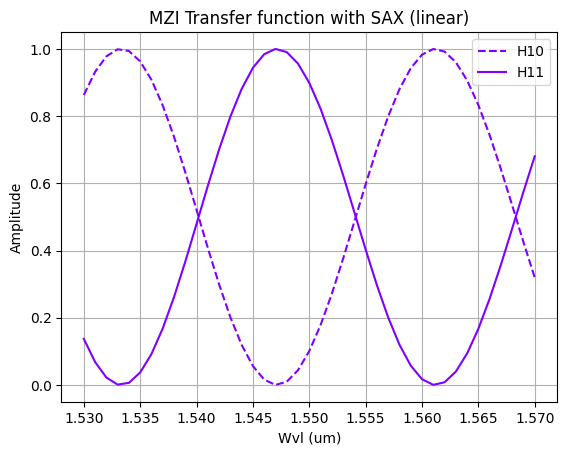

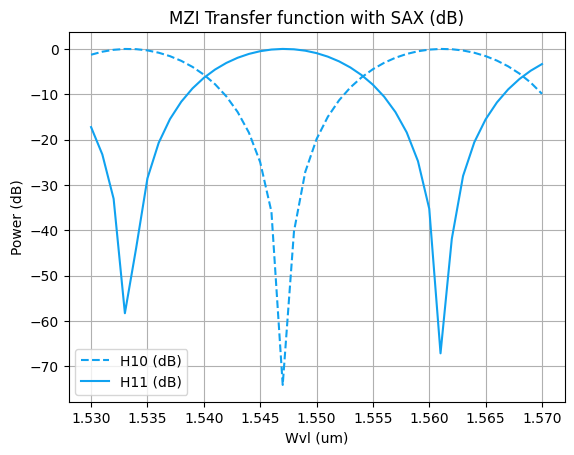

In [45]:
mzi_test = mzi(wl=wvl,
    coup_a = {"coupling": K_a},
    wvg_d={"length": Ld, "neff": neffd, "loss": alphad},
    wvg_u={"length": Lu, "neff": neffu, "loss": alphau},
    coup_b = {"coupling": K_b} )

H00 = mzi_test["in0", "out0"]
H10 = mzi_test["in0", "out1"]
H01 = mzi_test["in1", "out0"]
H11 = mzi_test["in1", "out1"]

H00_dB = 20 * jnp.log10(jnp.abs(H00)**2)  # Multiplicamos por 2 para normalizar la potencia de entrada
H10_dB = 20 * jnp.log10(jnp.abs(H10)**2)
H01_dB = 20 * jnp.log10(jnp.abs(H01)**2)
H11_dB = 20 * jnp.log10(jnp.abs(H11)**2)

# Plot
plt.figure()
#plt.plot(wvl, np.abs(H00)**2, linestyle='-', color=color[1], label='H00')
plt.plot(wvl, np.abs(H10)**2, linestyle='--', color=color[0], label='H10')
#plt.plot(wvl, np.abs(H01)**2, linestyle='--', color=color[2], label='H01')
plt.plot(wvl, np.abs(H11)**2, linestyle='-', color=color[0], label='H11')
plt.xlabel('Wvl (um)')
plt.ylabel('Amplitude')
plt.title('MZI Transfer function with SAX (linear)')
plt.legend()
plt.grid(True)

plt.figure()
#plt.plot(wvl, H00_dB, linestyle='-', color=color[1], label='H00 (dB)')
plt.plot(wvl, H10_dB, linestyle='--', color=color[2], label='H10 (dB)')
#plt.plot(wvl, H01_dB, linestyle='--', color=color[2], label='H01 (dB)')
plt.plot(wvl, H11_dB, linestyle='-', color=color[2], label='H11 (dB)')
plt.xlabel('Wvl (um)')
plt.ylabel('Power (dB)')
plt.title('MZI Transfer function with SAX (dB)')
plt.legend()
plt.grid(True)
plt.show()



**Assessment 4.** Designing an MZI for filtering at a specific wavelength. Calculate and adjust the arm lengths to configure the MZI to have a maximum transmission at 1550 nm.

**Assessment 5.** Let's see how the response of the MZI variates with the effective index. Vary the effective index of one of the arms and analyze how the spectrum shifts. To do this, you can use the data provided in the .txt files entitled ‘SiN’.
Can you give an example of an application where this configuration is used?

**Assessment 6.** Explore how cascading two MZIs affects the transmission spectrum. To do so, design a system in which two MZIs are cascaded. Simulate and observe the spectrum, explaining how the transmission peaks behave.

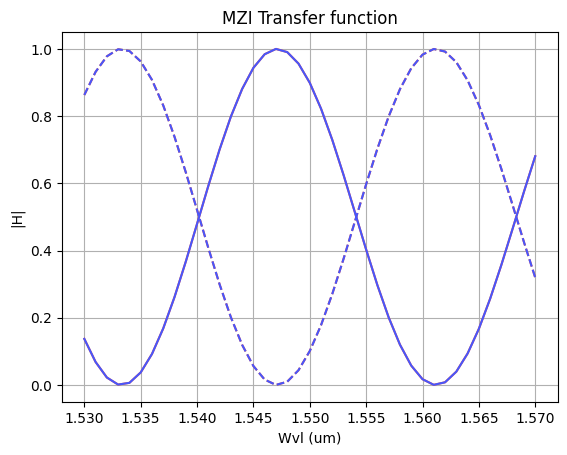

In [46]:
mzi_test = mzi(wl=wvl,
            coup_a={"coupling":K_a},
            wvg_u={"wl":wvl, "neff":neffu, "length": Lu, "loss":alphau},
            wvg_d={"wl":wvl, "neff":neffd, "length": Ld, "loss":alphad},
            coup_b={"coupling":K_b},
            )

h00 = mzi_test["in0", "out0"]
h01 = mzi_test["in0", "out1"]
h11 = mzi_test["in1", "out1"]
h10 = mzi_test["in1", "out0"]


# Plot
plt.figure()
plt.plot(wvl, np.abs(h11)**2, linestyle="-", color=color[8], label=f"h11")
plt.plot(wvl, np.abs(h10)**2, linestyle="--", color=color[8], label=f"h10")
plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.grid(True)
plt.show()


### Assessment 4

Designing an MZI for filtering at a specific wavelength. Calculate and adjust the arm lengths to configure the MZI to have a maximum transmission at 1550 nm.


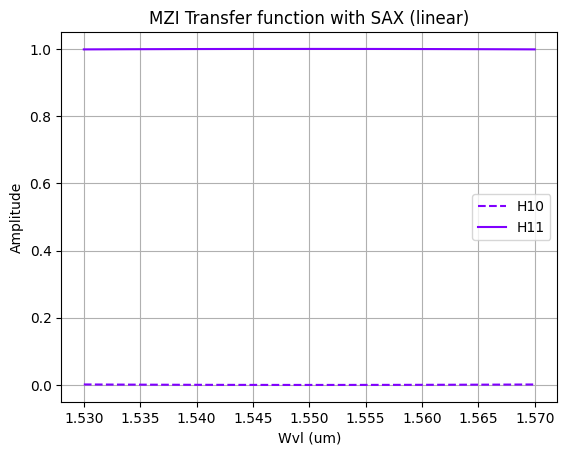

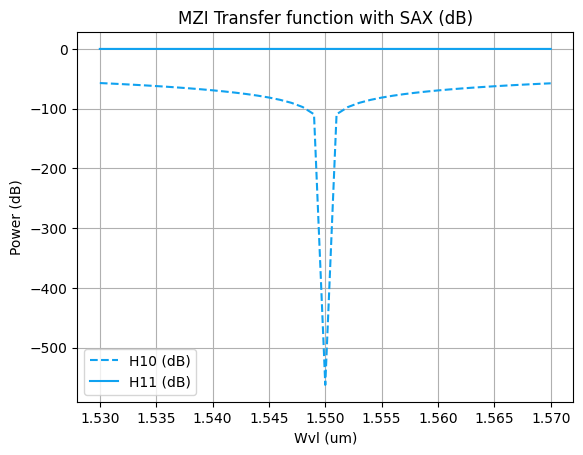

In [49]:
## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Path length
# Para tener transmisión máxima a 1550 nm, establecer la diferencia de fase en π a λ0 = 1.55 um
# Δφ = 2π (neffu Lu - neffd Ld) / λ0 = π, por lo que neffu Lu - neffd Ld = λ0 / 2
# Asumiendo neffu ≈ neffd ≈ neff a 1550 nm, ΔL = Lu - Ld ≈ λ0 / (2 * neff)
neff_at_1550 = neffu[20]  # Índice efectivo correspondiente a 1550 nm, que es el centro del rango espectral de interés
delta_L = 1.55 / (2 * neff_at_1550)
Lu = 25; # um
Ld = Lu - delta_L; # um

# Coupling constant
K_a = np.full(wvl.shape, 0.5) # Hace un arrary con el mismo valor de acoplamiento (0.5) para todas las longitudes de onda
K_b = np.full(wvl.shape, 0.5)

mzi_test = mzi(wl=wvl,
    coup_a = {"coupling": K_a},
    wvg_d={"length": Ld, "neff": neffd, "loss": alphad},
    wvg_u={"length": Lu, "neff": neffu, "loss": alphau},
    coup_b = {"coupling": K_b} )

H00 = mzi_test["in0", "out0"]
H10 = mzi_test["in0", "out1"]
H01 = mzi_test["in1", "out0"]
H11 = mzi_test["in1", "out1"]

H00_dB = 20 * jnp.log10(jnp.abs(H00)**2)  # Multiplicamos por 2 para normalizar la potencia de entrada
H10_dB = 20 * jnp.log10(jnp.abs(H10)**2)
H01_dB = 20 * jnp.log10(jnp.abs(H01)**2)
H11_dB = 20 * jnp.log10(jnp.abs(H11)**2)

# Plot
plt.figure()
#plt.plot(wvl, np.abs(H00)**2, linestyle='-', color=color[1], label='H00')
plt.plot(wvl, np.abs(H10)**2, linestyle='--', color=color[0], label='H10')
#plt.plot(wvl, np.abs(H01)**2, linestyle='--', color=color[2], label='H01')
plt.plot(wvl, np.abs(H11)**2, linestyle='-', color=color[0], label='H11')
plt.xlabel('Wvl (um)')
plt.ylabel('Amplitude')
plt.title('MZI Transfer function with SAX (linear)')
plt.legend()
plt.grid(True)

plt.figure()
#plt.plot(wvl, H00_dB, linestyle='-', color=color[1], label='H00 (dB)')
plt.plot(wvl, H10_dB, linestyle='--', color=color[2], label='H10 (dB)')
#plt.plot(wvl, H01_dB, linestyle='--', color=color[2], label='H01 (dB)')
plt.plot(wvl, H11_dB, linestyle='-', color=color[2], label='H11 (dB)')
plt.xlabel('Wvl (um)')
plt.ylabel('Power (dB)')
plt.title('MZI Transfer function with SAX (dB)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
idx = np.argmin(np.abs(wvl - 1.55))

neff_u_1550 = neffu[idx]
neff_d_1550 = neffd[idx] #vemos que neffu y neffd son iguales en este caso

m = 50
DifL=1.55*m/neff_u_1550
print("Diferencia de longitud (um):", DifL)

In [ ]:
Ld = 5; # um
Lu = Ld + DifL

mzi_test = mzi(
    wl=wvl,
    coup_a={"coupling": 0.5},
    coup_b={"coupling": 0.5},
    wvg_d={"length": Ld, "neff": neffd},
    wvg_u={"length": Lu, "neff": neffu},
)

H00 = mzi_test["in0", "out0"]
H01 = mzi_test["in0", "out1"]

plt.grid()
plt.plot(wvl, np.abs(H00)**2, label='H00')
plt.plot(wvl, np.abs(H01)**2, label='H01')
plt.legend()
plt.show()

In [ ]:
## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Path length
Lu = 25; # um
Ld = 25; # um

# Coupling constant
K_a = np.full(wvl.shape, 0.5) # Hace un arrary con el mismo valor de acoplamiento (0.5) para todas las longitudes de onda
K_b = np.full(wvl.shape, 0.5)

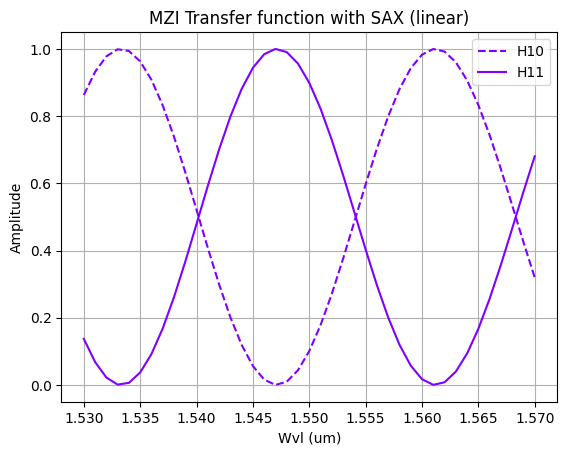

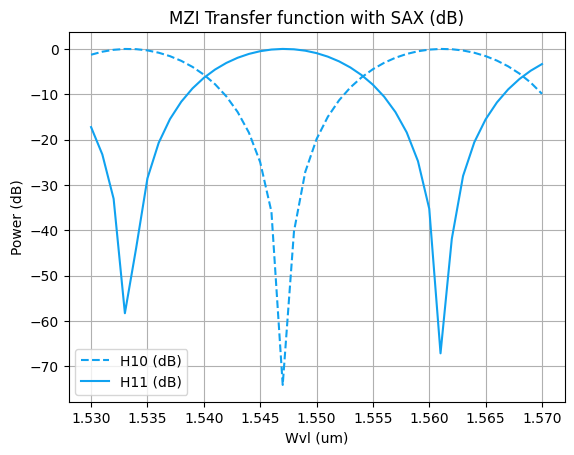

In [ ]:
mzi_test = mzi(wl=wvl,
    coup_a = {"coupling": K_a},
    wvg_d={"length": Ld, "neff": neffd, "loss": alphad},
    wvg_u={"length": Lu, "neff": neffu, "loss": alphau},
    coup_b = {"coupling": K_b} )

H00 = mzi_test["in0", "out0"]
H10 = mzi_test["in0", "out1"]
H01 = mzi_test["in1", "out0"]
H11 = mzi_test["in1", "out1"]

H00_dB = 20 * jnp.log10(jnp.abs(H00)**2)  # Multiplicamos por 2 para normalizar la potencia de entrada
H10_dB = 20 * jnp.log10(jnp.abs(H10)**2)
H01_dB = 20 * jnp.log10(jnp.abs(H01)**2)
H11_dB = 20 * jnp.log10(jnp.abs(H11)**2)

# Plot
plt.figure()
#plt.plot(wvl, np.abs(H00)**2, linestyle='-', color=color[1], label='H00')
plt.plot(wvl, np.abs(H10)**2, linestyle='--', color=color[0], label='H10')
#plt.plot(wvl, np.abs(H01)**2, linestyle='--', color=color[2], label='H01')
plt.plot(wvl, np.abs(H11)**2, linestyle='-', color=color[0], label='H11')
plt.xlabel('Wvl (um)')
plt.ylabel('Amplitude')
plt.title('MZI Transfer function with SAX (linear)')
plt.legend()
plt.grid(True)

plt.figure()
#plt.plot(wvl, H00_dB, linestyle='-', color=color[1], label='H00 (dB)')
plt.plot(wvl, H10_dB, linestyle='--', color=color[2], label='H10 (dB)')
#plt.plot(wvl, H01_dB, linestyle='--', color=color[2], label='H01 (dB)')
plt.plot(wvl, H11_dB, linestyle='-', color=color[2], label='H11 (dB)')
plt.xlabel('Wvl (um)')
plt.ylabel('Power (dB)')
plt.title('MZI Transfer function with SAX (dB)')
plt.legend()
plt.grid(True)
plt.show()


### Assessment 5

Let's see how the response of the MZI variates with the effective index. Vary the effective index of one of the arms and analyze how the spectrum shifts. To do this, you can use the data provided in the .txt files entitled ‘SiN’.
Can you give an example of an application where this configuration is used?


### Assessment 6

Explore how cascading two MZIs affects the transmission spectrum. To do so, design a system in which two MZIs are cascaded. Simulate and observe the spectrum, explaining how the transmission peaks behave.